In [1]:
from src.dataloading import EpiConfig, EpiDataOrchestrator
from src.dataloading import BaseLineDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, ConstantModel, ClimaScaleModel

epiconfig= EpiConfig(
        disease             = 'influenza',

        split_berlin        = False,

        horizon_leadtime    = 3,
        sequence_length     = 12,

        feature_popsize     = True,      
        feature_popdens     = True,
        feature_gisd        = True,
        feature_popage      = True,
        feature_kreise_classes= True,
        
        log_transform       = ['incidence']     
        )    

data_orch= EpiDataOrchestrator(epiconfig).build()

In [2]:
from src.dataloading import BaseLineDataLoaderManager, DeepDataLoaderManager,GraphDataLoaderManager

n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.2, 'patience': 5},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

baselinedataloader  = BaseLineDataLoaderManager(data_orch)
deepdataloader      = DeepDataLoaderManager(data_orch).build()
graphloader1        = GraphDataLoaderManager(data_orch).retrieve_static_graph('test2').build()


==                     lstm                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 39, 12), y=(400, 1))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.9267   |   1.5214   |    v     |           |
|  002  |   0.7038   |   0.9394   |    v     |           |
|  003  |   0.6072   |   0.6608   |    v     |           |
|  004  |   0.5500   |   0.6252   |    v     |           |
|  005  |   0.5083   |   0.5865   |    v     |           |
|  006  |   0.4858   |   0.5536   |    v     |           |
|  007  |   0.4684   |   0.5261   |    v     |           |
|  008  |   0.4553   |   0.5065   |    v     |           |
|  009  |   0.4458   |   0.4975   |    v     |           |
|  010  |   0.4392   |   0.4857   |    v     |           |
|  011  |   0.4320   |   0.4747   |    v     |           |
|  012  |   0.4226   |   0.4716   |    v     |           |
|  013  |   0.4249   |

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


trained ✓


Forecasting test: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 1114.53it/s]

Test loss: 0.5834
forecasted ✓


<Fig(n_axes = 1, legend, ticks, labels)>

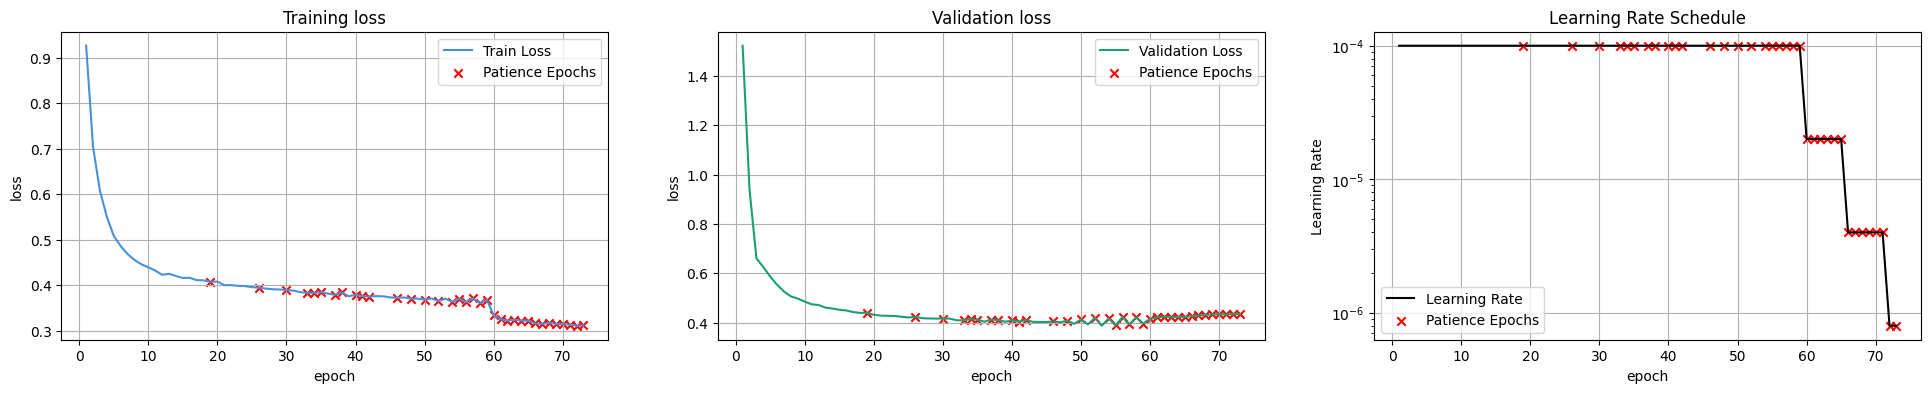

In [3]:
from src.models import LSTMModel, GCNLSTMModel

lstm = LSTMModel(deepdataloader, name = 'lstm', verbose = 2)
lstm.set_model_hparams(hidden_size=128, dropout = 0.3)
lstm.set_global_hparams(**global_hparams)
lstm.train()
lstm.forecast('test')
lstm.show_forecasts(26)



==                    dcpd1                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 39, 12), y=(400, 1), edge_index=(2, 2088), edge_weight=(2088,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.8626   |   1.2771   |    v     |           |
|  002  |   0.7109   |   0.9104   |    v     |           |
|  003  |   0.6217   |   0.7947   |    v     |           |
|  004  |   0.5928   |   0.6887   |    v     |           |
|  005  |   0.5559   |   0.6467   |    v     |           |
|  006  |   0.5409   |   0.5766   |    v     |           |
|  007  |   0.5204   |   0.5862   |          |   1/20    |
|  008  |   0.5165   |   0.5536   |    v     |           |
|  009  |   0.5041   |   0.5274   |    v     |           |
|  010  |   0.4953   |   0.5063   |    v     |           |
|  011  |   0.4929   |   0.5038   |    v     |           |
|  012  |   0.4793   |   0.4872   |  

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3679
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 331.91it/s]


Test loss: 0.5776
forecasted ✓


<Fig(n_axes = 1, legend, ticks, labels)>

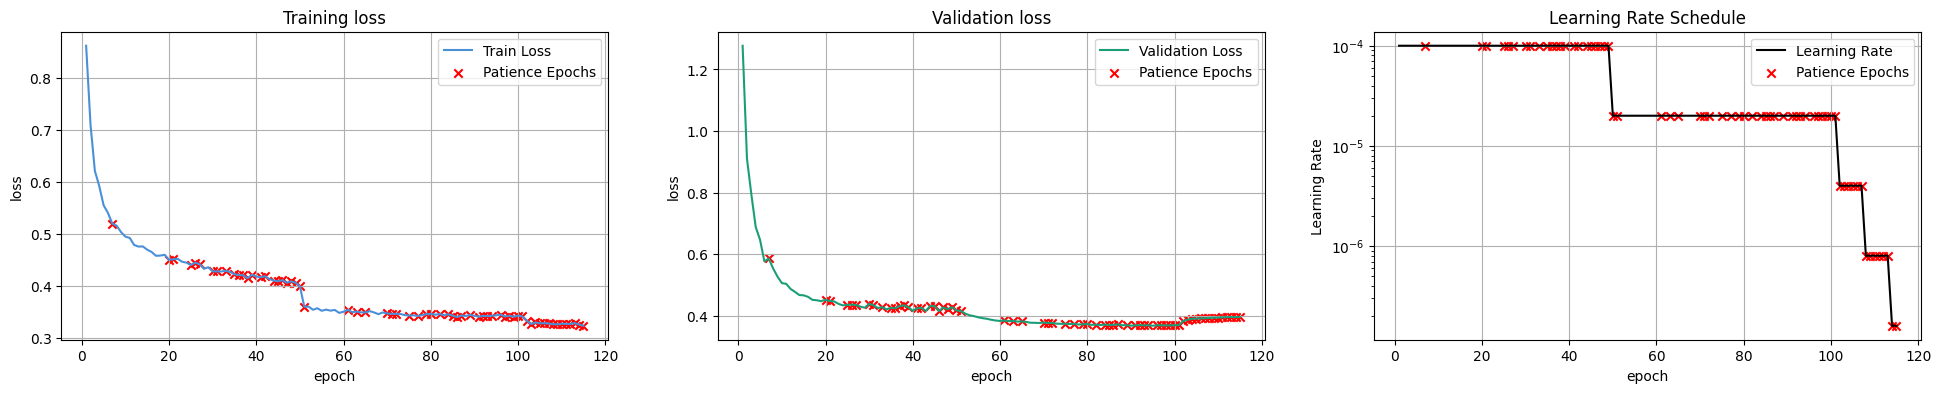

In [5]:
from src.models import GCN2Model
graphloader2        = GraphDataLoaderManager(data_orch).retrieve_static_graph('test1').build()
dcpd = GCN2Model(graphloader2, name = 'dcpd1', verbose = 2)
dcpd.set_model_hparams(dropout = 0.3, self_loops=True)
dcpd.set_global_hparams(**global_hparams)
dcpd.train()
dcpd.forecast('test')
dcpd.show_forecasts(26)


==                    dcpd2                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 39, 12), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.9008   |   1.1941   |    v     |           |
|  002  |   0.6941   |   0.9290   |    v     |           |
|  003  |   0.6334   |   0.7583   |    v     |           |
|  004  |   0.5885   |   0.6875   |    v     |           |
|  005  |   0.5687   |   0.6202   |    v     |           |
|  006  |   0.5523   |   0.5769   |    v     |           |
|  007  |   0.5400   |   0.5632   |    v     |           |
|  008  |   0.5316   |   0.5256   |    v     |           |
|  009  |   0.5233   |   0.5154   |    v     |           |
|  010  |   0.5153   |   0.4960   |    v     |           |
|  011  |   0.5036   |   0.4909   |    v     |           |
|  012  |   0.5008   |   0.4784   |    

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3938
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 358.62it/s]


Test loss: 0.6502
forecasted ✓


<Fig(n_axes = 1, legend, ticks, labels)>

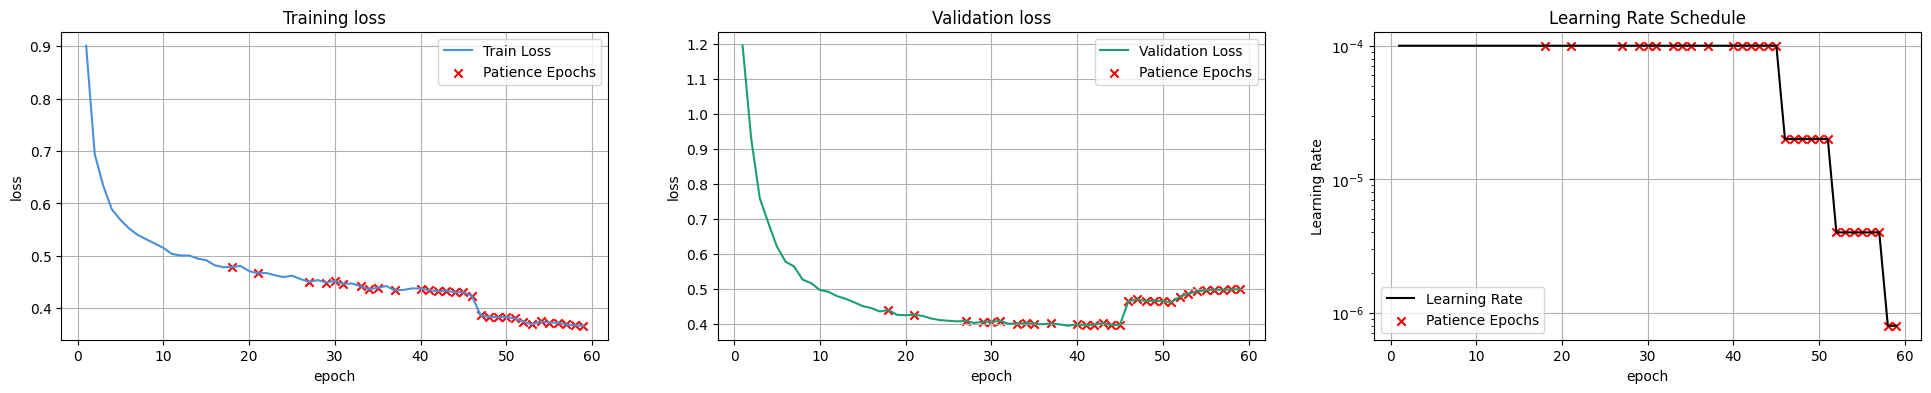

In [6]:
from src.models import GCN2Model
graphloader3        = GraphDataLoaderManager(data_orch).retrieve_static_graph('test3').build()
dcpd2 = GCN2Model(graphloader3, name = 'dcpd2', verbose = 2)
dcpd2.set_model_hparams(dropout = 0.3, self_loops=True)
dcpd2.set_global_hparams(**global_hparams)
dcpd2.train()
dcpd2.forecast('test')
dcpd2.show_forecasts(26)

In [7]:
from src.models import ClimaScaleModel, PersistenceModel, ClimateologyModel 
from src.evaluation import Evaluator

persistence = PersistenceModel(baselinedataloader)
persistence.forecast()

climateology = ClimateologyModel(baselinedataloader)
climateology.forecast()

climascale = ClimaScaleModel(baselinedataloader)
climascale.forecast()

baseline_models = [persistence, climateology, climascale]

In [8]:
models = baseline_models + [lstm,dcpd,dcpd2]

model_evaluation = Evaluator(models).add_evaluation()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2400/2400 [00:03<00:00, 763.28it/s]


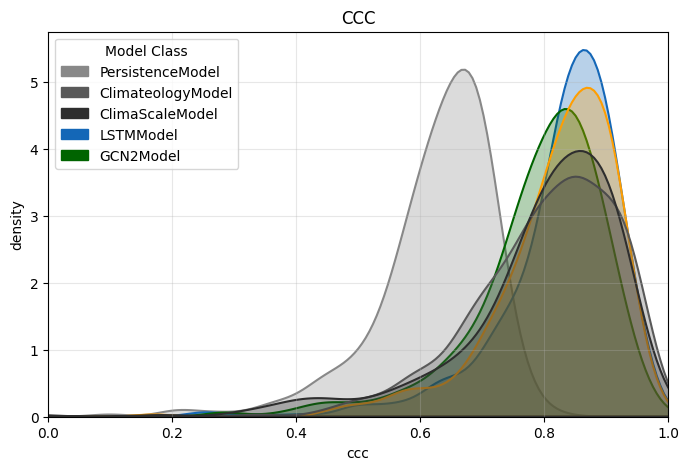

In [21]:
model_evaluation.plotter.plot_single_metric('ccc',0,plot_type = 'kde', vmin = 0, vmax=1, log=False).show()

  0%|                                                                                                                                                                                | 0/1600 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1600/1600 [00:02<00:00, 597.28it/s]


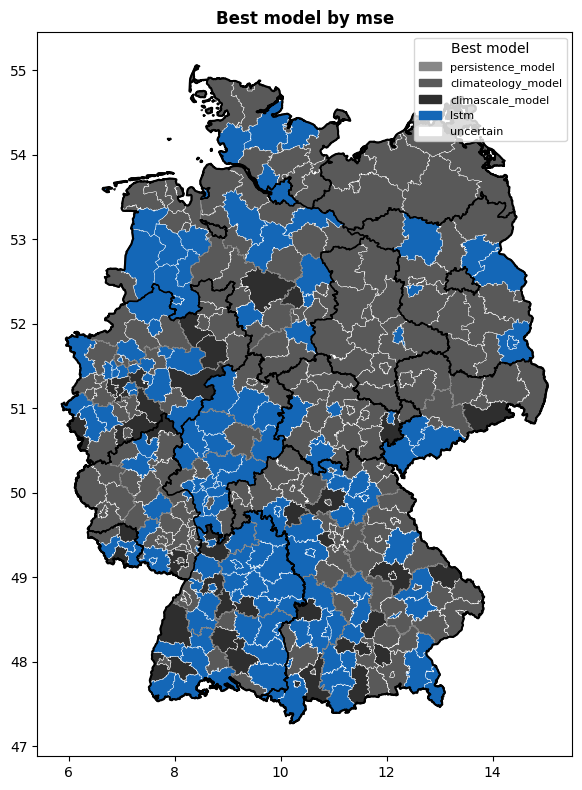

In [10]:
model_evaluation2 = Evaluator(baseline_models+[lstm]).add_evaluation()
model_evaluation2.plotter.plot_single_metric('mse',0, plot_type='best_map', margin_sd=0, best_lowest=True).show()

  0%|                                                                                                                                                                                | 0/1600 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1600/1600 [00:02<00:00, 756.05it/s]


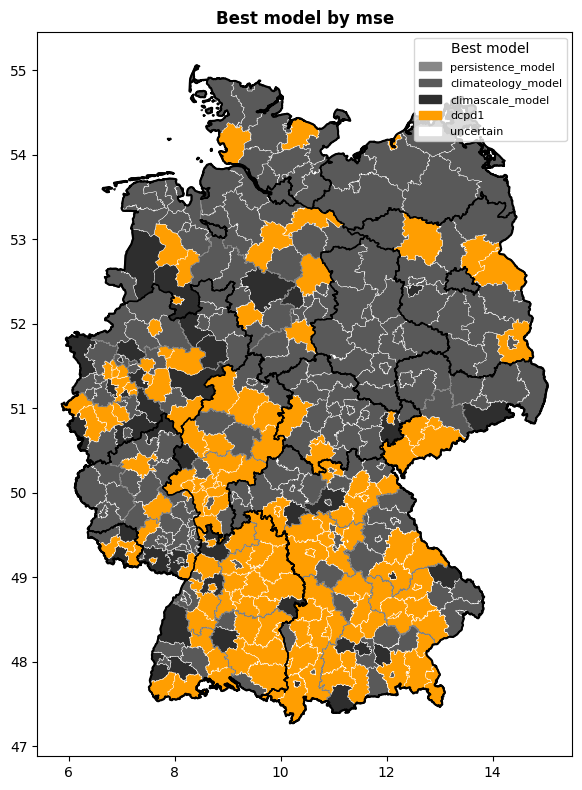

In [11]:
model_evaluation2 = Evaluator(baseline_models+[dcpd]).add_evaluation()
model_evaluation2.plotter.plot_single_metric('mse',0, plot_type='best_map', margin_sd=0, best_lowest=True).show()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1600/1600 [00:02<00:00, 755.10it/s]


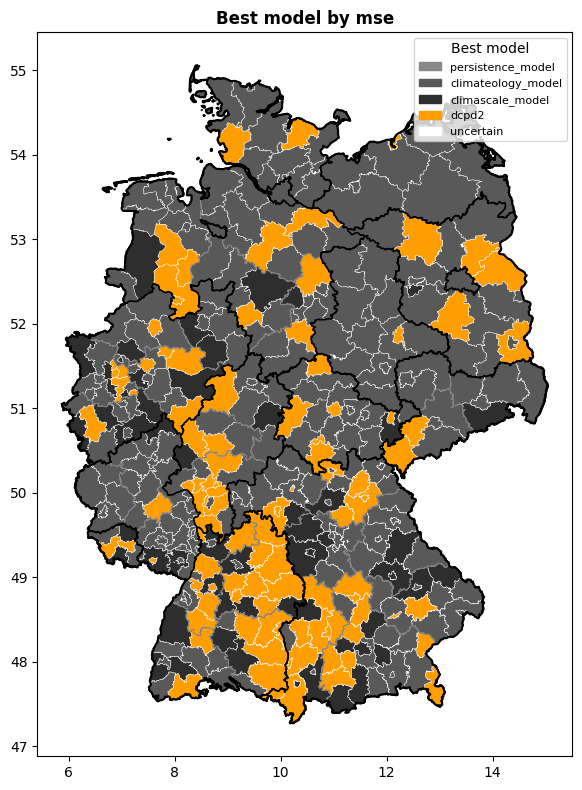

In [12]:
model_evaluation3 = Evaluator(baseline_models+[dcpd2]).add_evaluation()
model_evaluation3.plotter.plot_single_metric('mse',0, plot_type='best_map',margin_sd=0, best_lowest=True).show()

  0%|                                                                                                                                                                                | 0/1200 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1200/1200 [00:01<00:00, 745.66it/s]


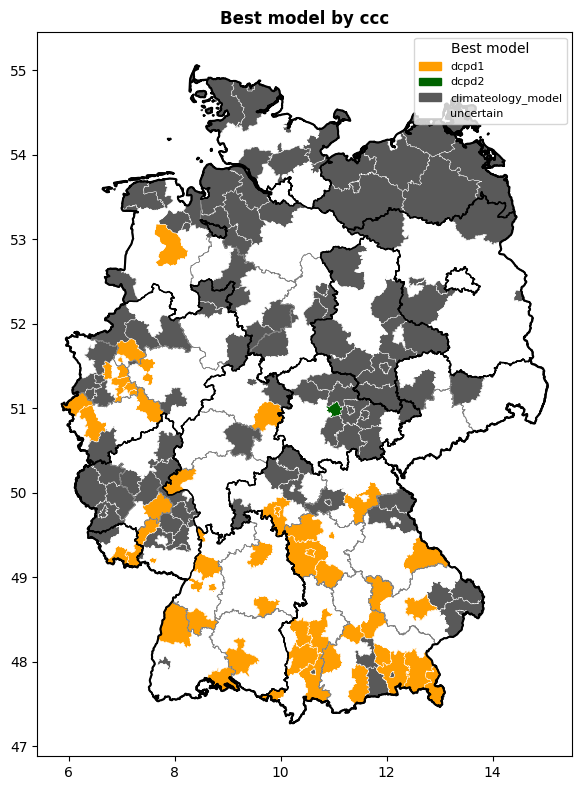

In [30]:
dcpd2.model_color = 'darkgreen'

model_evaluation3 = Evaluator([dcpd, dcpd2, climateology]).add_evaluation()
model_evaluation3.plotter.plot_single_metric('ccc',0, plot_type='best_map',margin_sd=1, best_lowest=False).show()

In [31]:
df = model_evaluation3.data_compilation.get_data(0,'test')['metrics']

metric = 'ccc'

df_wide = df[['nuts_node','model','ccc']]
df_wide = df_wide.pivot_table(index = 'nuts_node', columns = 'model', values = 'ccc').reset_index(drop = False)


In [42]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(df_wide['dcpd1'], df_wide['dcpd2'], alternative='greater')  # 'less' if lower is better
print(f"U={stat}, p={p}")

U=94716.0, p=1.7210418194491959e-06


In [34]:
from scipy.stats import kruskal

stat, p = kruskal(df_wide['dcpd1'], df_wide['dcpd2'], df_wide['climateology_model'])
print(f"H={stat}, p={p}")

H=19.603294326669584, p=5.536033677362336e-05


In [35]:
from itertools import combinations
from scipy.stats import mannwhitneyu

models = ['dcpd1', 'dcpd2', 'climateology_model']  # your model columns
alpha = 0.05
pairs = list(combinations(models, 2))

for a, b in pairs:
    x = df_wide[a].dropna()
    y = df_wide[b].dropna()
    stat, p = mannwhitneyu(x, y, alternative='greater')  # 'greater' if higher is better
    sig = '***' if p < alpha/len(pairs) else ''
    print(f"{a} vs {b}: U={stat:.1f}, p={p:.3e} {sig}")

dcpd1 vs dcpd2: U=94716.0, p=1.721e-06 ***
dcpd1 vs climateology_model: U=86261.0, p=2.040e-02 
dcpd2 vs climateology_model: U=73259.0, p=9.743e-01 


In [15]:
"""
spatial_autocorrelation.py
==========================
Moran's I analysis built entirely from your evaluator and models.
No graph constructor required.

Usage
-----
    from spatial_autocorrelation import run_spatial_analysis

    results = run_spatial_analysis(
        evaluator   = evaluator,
        name_geo    = 'your_geo_model_name',   # key in evaluator.evaluated_models
        name_id     = 'your_identity_model_name',
        dataset     = 'test',
        horizon     = 0,
    )
"""

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from typing import Tuple, Dict


# =============================================================================
# 1. BUILD WEIGHT MATRIX FROM SHAPEDATA
# =============================================================================

def build_weight_matrix_from_shapedata(shapedata: gpd.GeoDataFrame,
                                       id_col: str) -> Tuple[np.ndarray, list]:
    """
    Build a row-standardised spatial weight matrix W purely from
    shapedata geometry — no RawGraphConstructor needed.

    Two polygons are neighbors if they 'touch' (share a border edge),
    which is exactly what _geographic_neighbors() does internally.

    Parameters
    ----------
    shapedata : gpd.GeoDataFrame  — model.context_data.shapedata_node
    id_col    : str               — model.epiconfig.id_column

    Returns
    -------
    W          : np.ndarray [num_nodes, num_nodes] — row-standardised
    node_order : list — sorted node ids, matching row/col order of W
    """
    gdf         = shapedata[[id_col, 'geometry']].sort_values(id_col).reset_index(drop=True)
    gdf         = gdf[gdf[id_col].notna()].reset_index(drop=True)
    node_order  = gdf[id_col].tolist()
    node_idx    = {nid: i for i, nid in enumerate(node_order)}
    n           = len(node_order)

    W = np.zeros((n, n), dtype=float)

    neighbors = gpd.sjoin(gdf, gdf, how='inner', predicate='touches')
    neighbors = neighbors[neighbors[f'{id_col}_left'].notna() & neighbors[f'{id_col}_right'].notna()]
    neighbors = neighbors[neighbors[f'{id_col}_left'] != neighbors[f'{id_col}_right']]

    for _, row in neighbors.iterrows():
        i = node_idx[row[f'{id_col}_left']]
        j = node_idx[row[f'{id_col}_right']]
        W[i, j] = 1.0

    # Row-standardise: each row sums to 1; isolated nodes stay zero
    row_sums = W.sum(axis=1, keepdims=True)
    W = np.where(row_sums > 0, W / row_sums, 0.0)

    return W, node_order


# =============================================================================
# 2. GLOBAL MORAN'S I + PERMUTATION TEST
# =============================================================================

def morans_i(values: np.ndarray, W: np.ndarray) -> float:
    """
    Global Moran's I:  I = (n / sum(W)) * (z'Wz / z'z)

    > 0 : neighbors tend to be similar (spatial clustering)
    ~ 0 : random
    < 0 : neighbors tend to be dissimilar
    """
    n           = len(values)
    z           = values - values.mean()
    numerator   = n * float(z @ W @ z)
    denominator = float(z @ z) * W.sum()
    return float('nan') if denominator == 0 else numerator / denominator


def morans_i_permutation_test(values: np.ndarray,
                              W: np.ndarray,
                              n_permutations: int = 999,
                              seed: int = 42) -> Tuple[float, float]:
    """
    Significance via random permutation.
    p-value = fraction of permutations where permuted I >= observed I.
    """
    rng         = np.random.default_rng(seed)
    observed    = morans_i(values, W)
    count_geq   = sum(
        morans_i(rng.permutation(values), W) >= observed
        for _ in range(n_permutations)
    )
    p_value = (count_geq + 1) / (n_permutations + 1)
    return observed, p_value


# =============================================================================
# 3. LOCAL MORAN'S I (LISA)
# =============================================================================

def local_morans_i(values: np.ndarray, W: np.ndarray) -> np.ndarray:
    """
    Local Moran's I per node:  I_i = z_i * (W @ z)_i / var(z)

    High positive  => node and neighbors are both high or both low (cluster)
    High negative  => node is surrounded by dissimilar neighbors (outlier)
    """
    z     = values - values.mean()
    var_z = np.var(z)
    if var_z == 0:
        return np.zeros(len(values))
    return (z * (W @ z)) / var_z


# =============================================================================
# 4. EXTRACT DATA FROM EVALUATOR / MODELS
# =============================================================================

def _get_preds(model, dataset: str, horizon: int) -> pd.DataFrame:
    return model.predictions.get_preds(dataset).get(
        horizon=horizon, is_original=True, spatially_aggregated=False
    )


def extract_targets(model, dataset: str, horizon: int) -> pd.DataFrame:
    time_col = model.epiconfig.temporal_column
    id_col   = model.epiconfig.id_column
    df       = _get_preds(model, dataset, horizon)
    return df[[time_col, id_col, 'target']].copy()


def extract_node_mean_incidence(model, dataset: str,
                                horizon: int, node_order: list) -> np.ndarray:
    id_col = model.epiconfig.id_column
    df     = extract_targets(model, dataset, horizon)
    return df.groupby(id_col)['target'].mean().reindex(node_order).values.astype(float)


def extract_peak_week_incidence(model, dataset: str,
                                horizon: int, node_order: list) -> Tuple[np.ndarray, object]:
    time_col  = model.epiconfig.temporal_column
    id_col    = model.epiconfig.id_column
    df        = extract_targets(model, dataset, horizon)
    peak_week = df.groupby(time_col)['target'].sum().idxmax()
    vals      = (
        df[df[time_col] == peak_week]
        .set_index(id_col)['target']
        .reindex(node_order)
        .values.astype(float)
    )
    return vals, peak_week


def extract_node_improvement(model_geo, model_id,
                             dataset: str, horizon: int,
                             node_order: list) -> pd.DataFrame:
    """
    Per-node mean absolute error, merged on [time_col, id_col] to be safe
    against any ordering differences between models.

    improvement > 0  =>  geo model is better on that node
    """
    time_col = model_geo.epiconfig.temporal_column
    id_col   = model_geo.epiconfig.id_column

    df_geo = _get_preds(model_geo, dataset, horizon)[[time_col, id_col, 'target', 'pred']]
    df_id  = (_get_preds(model_id, dataset, horizon)[[time_col, id_col, 'pred']]
              .rename(columns={'pred': 'pred_id'}))

    df = df_geo.merge(df_id, on=[time_col, id_col]).rename(columns={'pred': 'pred_geo'})
    df['ae_geo']      = (df['target'] - df['pred_geo']).abs()
    df['ae_id']       = (df['target'] - df['pred_id']).abs()
    df['improvement'] = df['ae_id'] - df['ae_geo']

    return (
        df.groupby(id_col)[['ae_geo', 'ae_id', 'improvement']]
        .mean()
        .reindex(node_order)
        .reset_index()
    )


def weekly_morans_i(model, dataset: str, horizon: int,
                    W: np.ndarray, node_order: list) -> pd.DataFrame:
    """Moran's I computed independently for every week."""
    time_col = model.epiconfig.temporal_column
    id_col   = model.epiconfig.id_column
    df       = extract_targets(model, dataset, horizon)

    # Diagnose alignment between prediction node ids and node_order
    pred_nodes = set(df[id_col].unique())
    W_nodes    = set(node_order)
    if pred_nodes != W_nodes:
        only_in_preds = pred_nodes - W_nodes
        only_in_W     = W_nodes - pred_nodes
        print(f"  WARNING: node id mismatch.")
        print(f"    In predictions but not W : {len(only_in_preds)} nodes — e.g. {list(only_in_preds)[:3]}")
        print(f"    In W but not predictions : {len(only_in_W)} nodes — e.g. {list(only_in_W)[:3]}")

    results = []
    skipped_nan = 0
    skipped_var = 0

    for timestamp, week_df in df.groupby(time_col):
        vals = (week_df.set_index(id_col)['target']
                       .reindex(node_order).values.astype(float))
        if np.isnan(vals).any():
            skipped_nan += 1
            # fill NaN with the week mean so the week isn't lost entirely
            vals = np.where(np.isnan(vals), np.nanmean(vals), vals)
        if np.nanstd(vals) == 0:
            skipped_var += 1
            continue
        results.append({'timestamp': timestamp, 'morans_i': morans_i(vals, W)})

    if skipped_nan:
        print(f"  {skipped_nan} weeks had NaN nodes (filled with week mean)")
    if skipped_var:
        print(f"  {skipped_var} weeks skipped (zero variance)")

    if not results:
        raise ValueError(
            "No weeks produced a valid Moran's I. "
            "Check that node ids in predictions match those in shapedata. "
            f"Prediction id sample: {list(pred_nodes)[:5]}, "
            f"node_order sample: {node_order[:5]}"
        )

    return pd.DataFrame(results).sort_values('timestamp').reset_index(drop=True)


# =============================================================================
# 5. PLOTS
# =============================================================================

def _plot_weekly(weekly_df, ax):
    ax.plot(weekly_df['timestamp'], weekly_df['morans_i'],
            color='steelblue', linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title("Global Moran's I per week")
    ax.set_xlabel("Week")
    ax.set_ylabel("Moran's I")
    ax.tick_params(axis='x', rotation=45)


def _plot_lisa_map(local_I, shapedata, id_col, node_order, title, ax):
    lisa_df  = pd.DataFrame({id_col: node_order, 'local_I': local_I})
    gdf_plot = shapedata.merge(lisa_df, on=id_col, how='left')
    vmax     = np.abs(local_I[~np.isnan(local_I)]).max()
    norm     = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    gdf_plot.plot(column='local_I', cmap='RdBu_r', norm=norm,
                  edgecolor='grey', linewidth=0.2, ax=ax, legend=True)
    ax.set_title(title)
    ax.axis('off')


def _plot_scatter(node_errors, local_I, id_col, node_order, ax):
    lisa_df = pd.DataFrame({id_col: node_order, 'local_I': local_I})
    merged  = node_errors.merge(lisa_df, on=id_col)
    ax.scatter(merged['local_I'], merged['improvement'],
               alpha=0.5, s=20, color='steelblue', edgecolors='none')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    r = np.corrcoef(merged['local_I'], merged['improvement'])[0, 1]
    ax.set_title(f"Local Moran's I vs. geo improvement  (r = {r:.3f})")
    ax.set_xlabel("Local Moran's I (mean incidence)")
    ax.set_ylabel("MAE improvement: identity − geo")
    return r


# =============================================================================
# 6. MAIN ENTRY POINT
# =============================================================================

def run_spatial_analysis(evaluator,
                         name_geo:       str,
                         name_id:        str,
                         dataset:        str = 'test',
                         horizon:        int = 0,
                         n_permutations: int = 999) -> Dict:
    """
    Full spatial autocorrelation analysis from an Evaluator.

    Parameters
    ----------
    evaluator       : your Evaluator object
    name_geo        : name of the geographic-graph model (key in evaluator.evaluated_models)
    name_id         : name of the identity-graph model
    dataset         : 'train', 'val', or 'test'
    horizon         : forecast horizon index
    n_permutations  : permutation test iterations for significance

    Returns
    -------
    dict with W, node_order, Moran's I values, weekly df, local I arrays, node errors
    Also saves figure to spatial_autocorrelation.png
    """
    model_geo = evaluator.evaluated_models[name_geo]
    model_id  = evaluator.evaluated_models[name_id]
    id_col    = model_geo.epiconfig.id_column
    shapedata = model_geo.context_data.shapedata_node

    print("Building spatial weight matrix from shapedata geometry...")
    W, node_order = build_weight_matrix_from_shapedata(shapedata, id_col)
    print(f"  {len(node_order)} nodes, {int(W.astype(bool).sum())} neighbor pairs")

    mean_inc            = extract_node_mean_incidence(model_geo, dataset, horizon, node_order)
    peak_inc, peak_week = extract_peak_week_incidence(model_geo, dataset, horizon, node_order)
    print(f"  Peak week: {peak_week}")

    print(f"\nPermutation test ({n_permutations} iterations)...")
    I_mean, p_mean = morans_i_permutation_test(mean_inc, W, n_permutations)
    I_peak, p_peak = morans_i_permutation_test(peak_inc, W, n_permutations)

    print(f"\n{'='*54}")
    print(f"  Global Moran's I — mean incidence : {I_mean:+.4f}  (p = {p_mean:.4f})")
    print(f"  Global Moran's I — peak week      : {I_peak:+.4f}  (p = {p_peak:.4f})")
    print(f"{'='*54}")
    if   I_mean > 0.05 and p_mean < 0.05:
        print("  >> Significant positive spatial autocorrelation.")
        print("     Geographic graph is supported by the data.")
    elif p_mean >= 0.05:
        print("  >> No significant spatial autocorrelation detected.")
    else:
        print("  >> Weak or ambiguous spatial signal.")

    local_I_mean = local_morans_i(mean_inc, W)
    local_I_peak = local_morans_i(peak_inc, W)

    print("\nComputing weekly Moran's I...")
    weekly_df = weekly_morans_i(model_geo, dataset, horizon, W, node_order)

    print("Computing per-node improvement (geo vs identity)...")
    node_errors = extract_node_improvement(model_geo, model_id, dataset, horizon, node_order)
    pct_better  = (node_errors['improvement'] > 0).mean() * 100
    print(f"  Geo model better on {pct_better:.1f}% of nodes")

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    _plot_weekly(weekly_df, axes[0, 0])
    _plot_lisa_map(local_I_mean, shapedata, id_col, node_order,
                   "Local Moran's I — mean incidence", axes[0, 1])
    _plot_lisa_map(local_I_peak, shapedata, id_col, node_order,
                   f"Local Moran's I — peak week ({peak_week})", axes[1, 0])
    r = _plot_scatter(node_errors, local_I_mean, id_col, node_order, axes[1, 1])

    fig.suptitle(
        f"Spatial Autocorrelation  |  {name_geo} vs {name_id}  |  {dataset}, horizon={horizon}\n"
        f"Global Moran's I (mean): {I_mean:+.3f} (p={p_mean:.3f})  |  "
        f"Geo better on {pct_better:.0f}% of nodes  |  r(LISA, improvement) = {r:.3f}",
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig('spatial_autocorrelation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nFigure saved → spatial_autocorrelation.png")

    return {
        'W'            : W,
        'node_order'   : node_order,
        'I_mean'       : I_mean,
        'p_mean'       : p_mean,
        'I_peak'       : I_peak,
        'p_peak'       : p_peak,
        'local_I_mean' : local_I_mean,
        'local_I_peak' : local_I_peak,
        'weekly_df'    : weekly_df,
        'node_errors'  : node_errors,
    }

In [14]:
evaluator

NameError: name 'evaluator' is not defined

Building spatial weight matrix from shapedata geometry...
  400 nodes, 2088 neighbor pairs
  Peak week: 2020-03-02 00:00:00

Permutation test (999 iterations)...

  Global Moran's I — mean incidence : +0.6847  (p = 0.0010)
  Global Moran's I — peak week      : +0.4336  (p = 0.0010)
  >> Significant positive spatial autocorrelation.
     Geographic graph is supported by the data.

Computing weekly Moran's I...
Computing per-node improvement (geo vs identity)...
  Geo model better on 58.5% of nodes


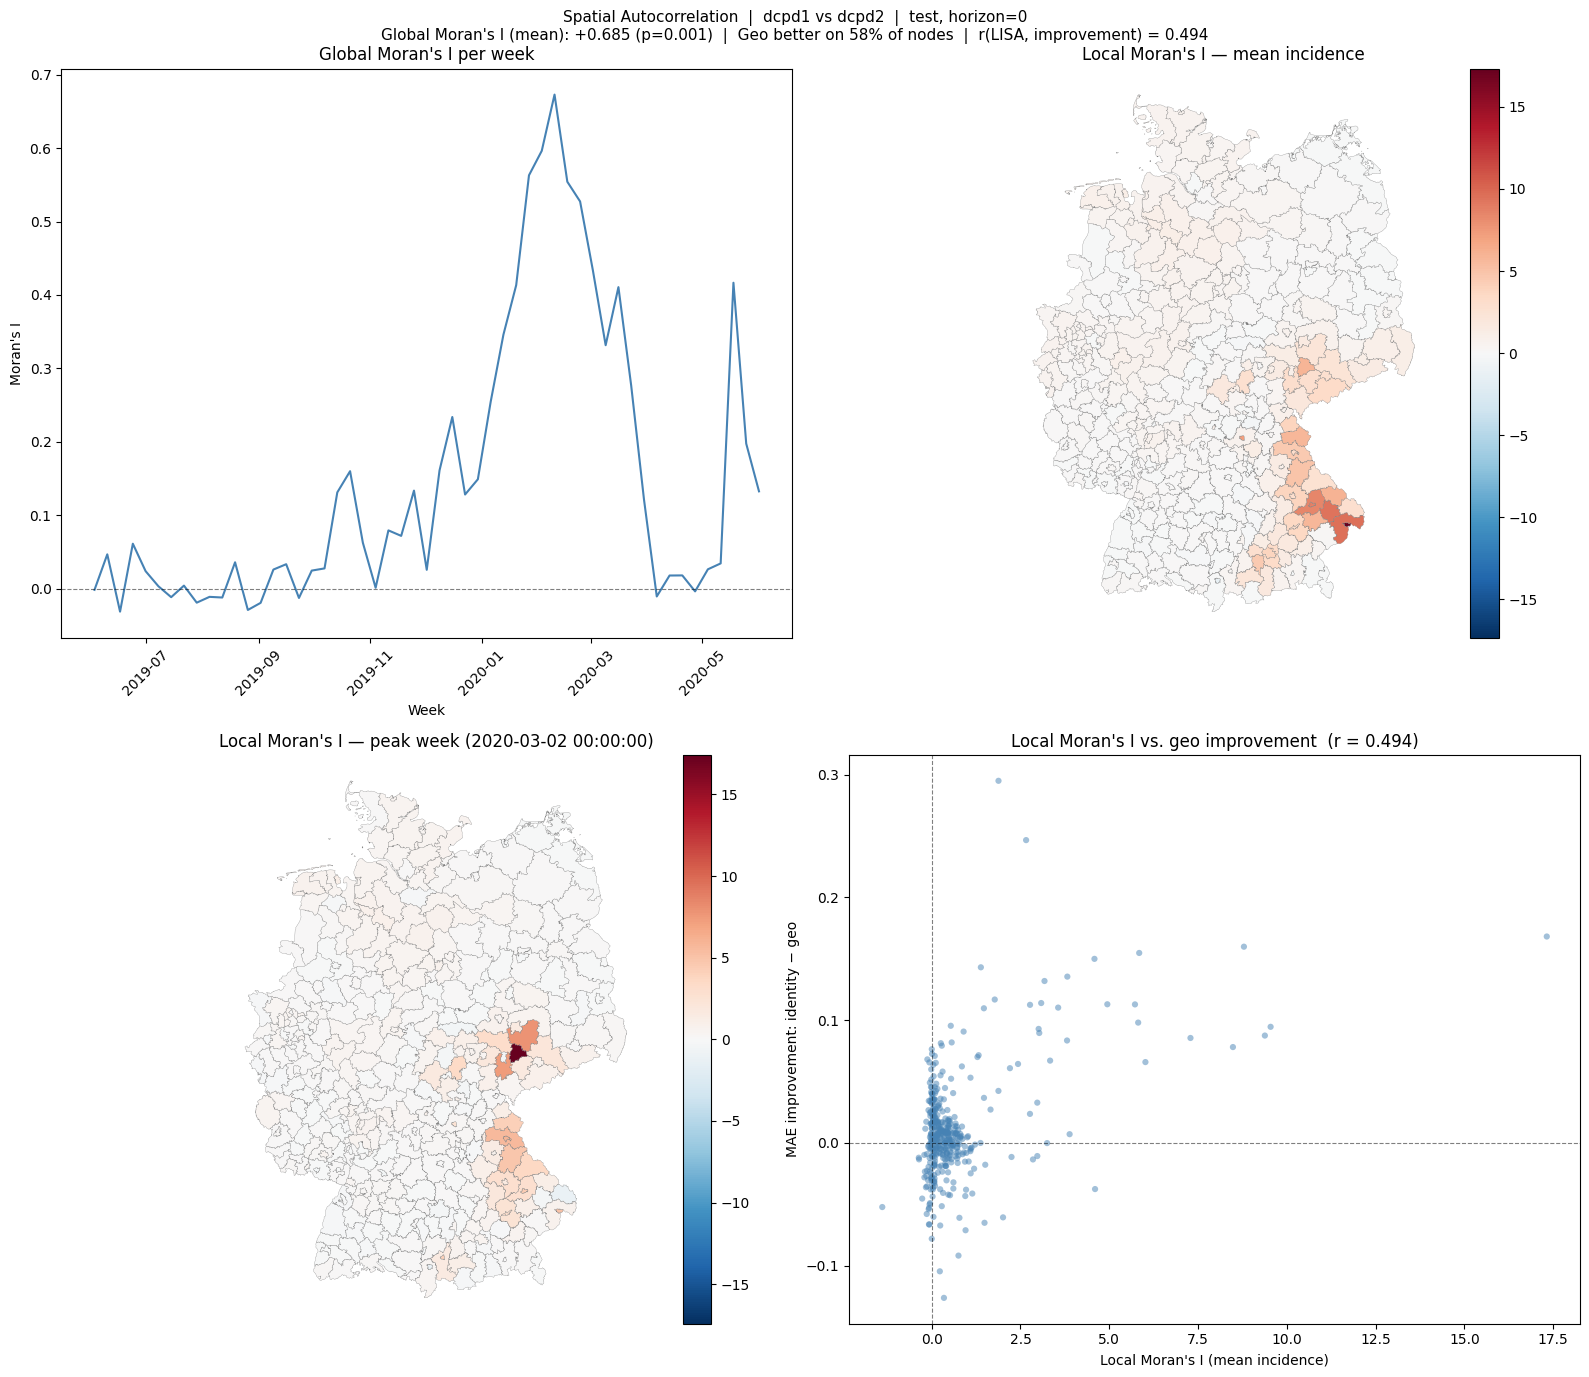


Figure saved → spatial_autocorrelation.png


In [ ]:

results = run_spatial_analysis(
    evaluator = ev,
    name_geo  = 'dcpd1',  # exact key in evaluator.evaluated_models
    name_id   = 'dcpd2',
    dataset   = 'test',
    horizon   = 0,
)